### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [2]:
df_total = pd.concat([tienda, tienda2, tienda3, tienda4])
df_total['Facturación'] = df_total['Precio'] + df_total['Costo de envío']
total_facturacion = df_total['Facturación'].sum()

In [3]:
print(f"El total de facturación de todas las tiendas es: {total_facturacion:,.2f}")

El total de facturación de todas las tiendas es: 4,638,316,200.00


# 2. Ventas por categoría

In [4]:
ventas_por_categoria = df_total.groupby('Categoría del Producto')['Facturación'].sum().sort_values(ascending=False)
print("Ventas por Categoría de Producto:")
print(ventas_por_categoria)

Ventas por Categoría de Producto:
Categoría del Producto
Electrónicos               1.749039e+09
Electrodomésticos          1.395147e+09
Muebles                    7.981114e+08
Instrumentos musicales     3.672769e+08
Deportes y diversión       1.506693e+08
Juguetes                   7.762570e+07
Artículos para el hogar    6.069090e+07
Libros                     3.975600e+07
Name: Facturación, dtype: float64


El análisis de `ventas_por_categoria` nos muestra las categorías de productos con mayor facturación en todas las tiendas combinadas.

# 3. Calificación promedio de la tienda


In [5]:
calificacion_tienda1 = tienda['Calificación'].mean()
calificacion_tienda2 = tienda2['Calificación'].mean()
calificacion_tienda3 = tienda3['Calificación'].mean()
calificacion_tienda4 = tienda4['Calificación'].mean()

print(f"Calificación promedio Tienda 1: {calificacion_tienda1:.2f}")
print(f"Calificación promedio Tienda 2: {calificacion_tienda2:.2f}")
print(f"Calificación promedio Tienda 3: {calificacion_tienda3:.2f}")
print(f"Calificación promedio Tienda 4: {calificacion_tienda4:.2f}")

Calificación promedio Tienda 1: 3.98
Calificación promedio Tienda 2: 4.04
Calificación promedio Tienda 3: 4.05
Calificación promedio Tienda 4: 4.00


# 4. Productos más y menos vendidos

In [6]:
tiendas = {'Tienda 1': tienda, 'Tienda 2': tienda2, 'Tienda 3': tienda3, 'Tienda 4': tienda4}

for nombre_tienda, df_tienda in tiendas.items():
    productos_vendidos = df_tienda['Producto'].value_counts()

    if not productos_vendidos.empty:
        producto_mas_vendido = productos_vendidos.idxmax()
        cantidad_mas_vendido = productos_vendidos.max()
        producto_menos_vendido = productos_vendidos.idxmin()
        cantidad_menos_vendido = productos_vendidos.min()

        print(f"\n--- {nombre_tienda} ---")
        print(f"Producto más vendido: {producto_mas_vendido} (Cantidad: {cantidad_mas_vendido})")
        print(f"Producto menos vendido: {producto_menos_vendido} (Cantidad: {cantidad_menos_vendido})")
    else:
        print(f"\n--- {nombre_tienda} ---")
        print("No hay datos de productos para esta tienda.")


--- Tienda 1 ---
Producto más vendido: Microondas (Cantidad: 60)
Producto menos vendido: Auriculares con micrófono (Cantidad: 33)

--- Tienda 2 ---
Producto más vendido: Iniciando en programación (Cantidad: 65)
Producto menos vendido: Juego de mesa (Cantidad: 32)

--- Tienda 3 ---
Producto más vendido: Kit de bancas (Cantidad: 57)
Producto menos vendido: Bloques de construcción (Cantidad: 35)

--- Tienda 4 ---
Producto más vendido: Cama box (Cantidad: 62)
Producto menos vendido: Guitarra eléctrica (Cantidad: 33)


# 5. Envío promedio por tienda

In [7]:
for nombre_tienda, df_tienda in tiendas.items():
    envio_promedio = df_tienda['Costo de envío'].mean()
    print(f"Costo de envío promedio en {nombre_tienda}: {envio_promedio:.2f}")

Costo de envío promedio en Tienda 1: 26018.61
Costo de envío promedio en Tienda 2: 25216.24
Costo de envío promedio en Tienda 3: 24805.68
Costo de envío promedio en Tienda 4: 23459.46


#Visualizacion

/tmp/ipykernel_914/3435301511.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_categoria.index, y=ventas_por_categoria.values, palette='viridis')


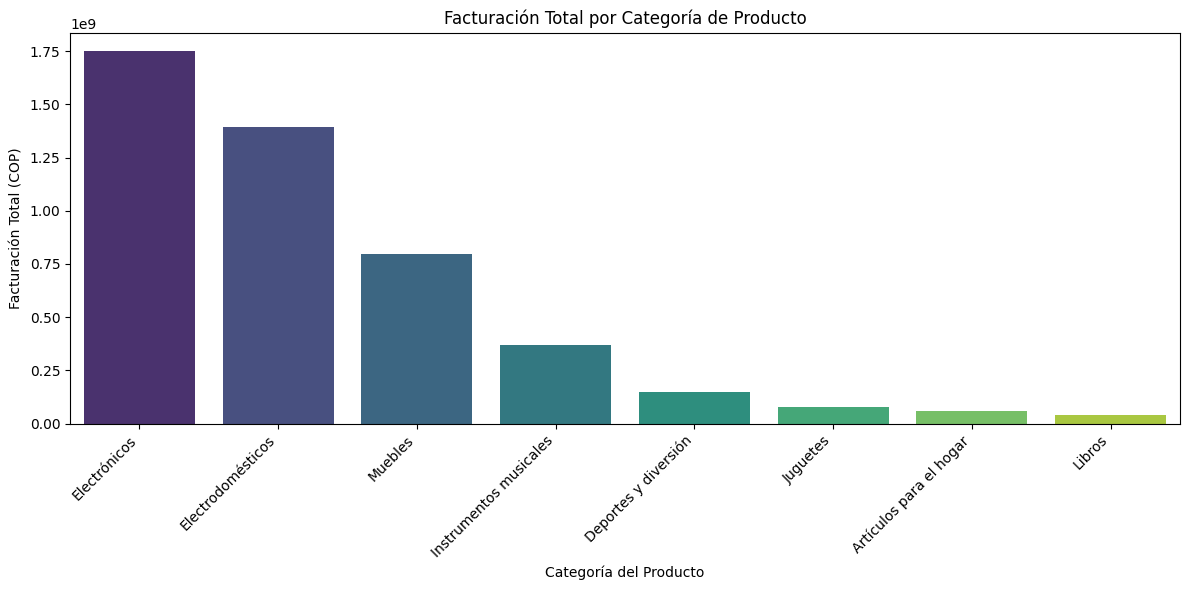

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de barras para ventas por categoría
plt.figure(figsize=(12, 6))
sns.barplot(x=ventas_por_categoria.index, y=ventas_por_categoria.values, palette='viridis')
plt.title('Facturación Total por Categoría de Producto')
plt.xlabel('Categoría del Producto')
plt.ylabel('Facturación Total (COP)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_914/1971826245.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tienda', y='Calificación Promedio', data=df_calificaciones, palette='coolwarm')


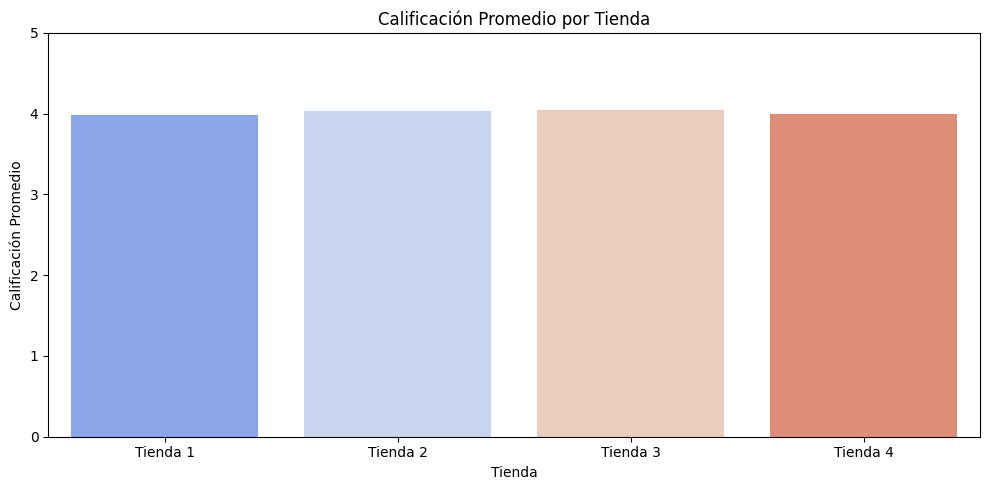

In [9]:
# Gráfico de barras para la calificación promedio por tienda
calificaciones = {
    'Tienda 1': calificacion_tienda1,
    'Tienda 2': calificacion_tienda2,
    'Tienda 3': calificacion_tienda3,
    'Tienda 4': calificacion_tienda4
}
df_calificaciones = pd.DataFrame(calificaciones.items(), columns=['Tienda', 'Calificación Promedio'])

plt.figure(figsize=(10, 5))
sns.barplot(x='Tienda', y='Calificación Promedio', data=df_calificaciones, palette='coolwarm')
plt.title('Calificación Promedio por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Calificación Promedio')
plt.ylim(0, 5) # Las calificaciones suelen ser de 1 a 5
plt.tight_layout()
plt.show()

/tmp/ipykernel_914/277221919.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tienda', y='Costo de Envío Promedio', data=df_envios, palette='mako')


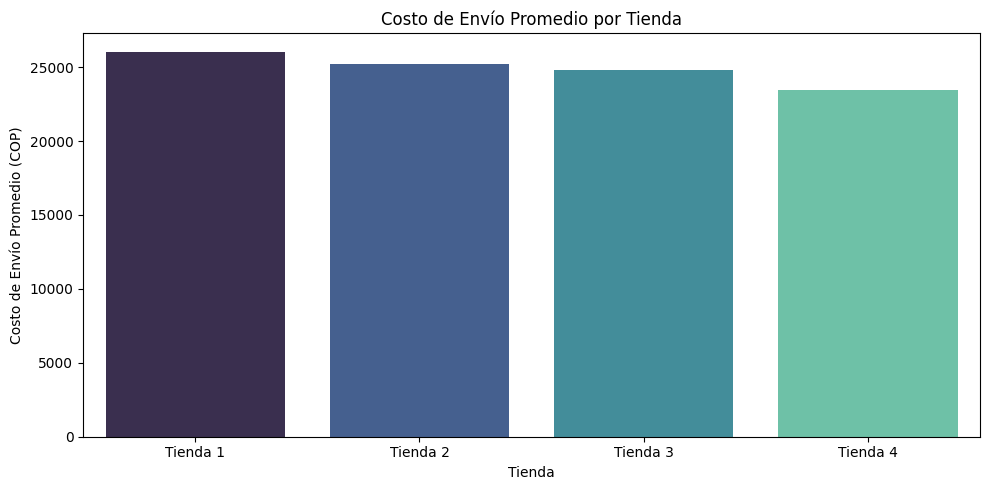

In [10]:
# Gráfico de barras para el costo de envío promedio por tienda
envios = {
    'Tienda 1': tienda['Costo de envío'].mean(),
    'Tienda 2': tienda2['Costo de envío'].mean(),
    'Tienda 3': tienda3['Costo de envío'].mean(),
    'Tienda 4': tienda4['Costo de envío'].mean()
}
df_envios = pd.DataFrame(envios.items(), columns=['Tienda', 'Costo de Envío Promedio'])

plt.figure(figsize=(10, 5))
sns.barplot(x='Tienda', y='Costo de Envío Promedio', data=df_envios, palette='mako')
plt.title('Costo de Envío Promedio por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Costo de Envío Promedio (COP)')
plt.tight_layout()
plt.show()

## Informe Final: Recomendación de Venta para el Sr. Juan

### Introducción

El propósito de este informe es analizar el rendimiento operativo y comercial de cuatro tiendas (Tienda 1, Tienda 2, Tienda 3 y Tienda 4) con el fin de proporcionar al Sr. Juan una recomendación fundamentada sobre cuál de estas tiendas debería vender. El análisis se ha centrado en métricas clave como la facturación total, el rendimiento de ventas por categoría, la satisfacción del cliente (calificación promedio), los productos más y menos vendidos, y la eficiencia en los costos de envío. Al sintetizar estos datos, buscamos ofrecer una visión clara de las fortalezas y debilidades de cada establecimiento y justificar la decisión de venta.


### Desarrollo de los Hallazgos

#### 1. Facturación Total de las Tiendas

La facturación total combinada de todas las tiendas asciende a **4,638,316,200.00 COP**. Este dato representa el volumen general de negocio y sirve como punto de partida para entender la escala de las operaciones.

#### 2. Ventas por Categoría de Producto

El análisis de las ventas por categoría revela una clara dominancia de los **Electrónicos** y los **Electrodomésticos** en la facturación total. Estas categorías generan la mayor parte de los ingresos, mientras que categorías como 'Artículos para el hogar' y 'Libros' tienen una contribución menor. El gráfico de barras 'Facturación Total por Categoría de Producto' visualiza esta distribución, mostrando la importancia estratégica de las categorías de alta tecnología y bienes duraderos.

*   **Electrónicos:** 1.749 millones COP
*   **Electrodomésticos:** 1.395 millones COP
*   **Muebles:** 798 millones COP
*   **Instrumentos musicales:** 367 millones COP
*   **Deportes y diversión:** 150 millones COP
*   **Juguetes:** 77 millones COP
*   **Artículos para el hogar:** 60 millones COP
*   **Libros:** 39 millones COP

#### 3. Calificación Promedio de los Clientes por Tienda

Las calificaciones promedio de los clientes muestran un rendimiento consistente entre las tiendas, todas ellas rondando los 4 puntos sobre 5. La **Tienda 3** presenta la calificación más alta, aunque la diferencia es marginal.

*   **Tienda 1:** 3.98
*   **Tienda 2:** 4.04
*   **Tienda 3:** 4.05
*   **Tienda 4:** 4.00

El gráfico 'Calificación Promedio por Tienda' ilustra estas pequeñas variaciones, indicando que la satisfacción general del cliente es buena en todas las ubicaciones, con la Tienda 3 ligeramente por delante.

#### 4. Productos Más y Menos Vendidos por Tienda

Este análisis proporciona una visión detallada del inventario y la demanda específica de cada tienda:

*   **Tienda 1:** Producto más vendido: Microondas (60 unidades); Producto menos vendido: Auriculares con micrófono (33 unidades).
*   **Tienda 2:** Producto más vendido: Iniciando en programación (65 unidades); Producto menos vendido: Juego de mesa (32 unidades).
*   **Tienda 3:** Producto más vendido: Kit de bancas (57 unidades); Producto menos vendido: Bloques de construcción (35 unidades).
*   **Tienda 4:** Producto más vendido: Cama box (62 unidades); Producto menos vendido: Guitarra eléctrica (33 unidades).

Estos datos sugieren patrones de consumo localizados y posibles oportunidades para optimizar el inventario o estrategias de marketing dirigidas a los productos menos vendidos.

#### 5. Costo de Envío Promedio por Tienda

Los costos de envío promedio varían ligeramente entre las tiendas, siendo la **Tienda 4** la que registra el costo más bajo. Esto podría indicar una mayor eficiencia logística o una ubicación más favorable respecto a los centros de distribución o la clientela.

*   **Tienda 1:** 26018.61 COP
*   **Tienda 2:** 25216.24 COP
*   **Tienda 3:** 24805.68 COP
*   **Tienda 4:** 23459.46 COP

El gráfico 'Costo de Envío Promedio por Tienda' confirma que la Tienda 4 tiene un ligero, pero significativo, ahorro en este aspecto.


### Conclusión y Recomendación

Considerando todos los factores analizados, se recomienda al Sr. Juan que, si su objetivo es maximizar la eficiencia operativa y mantener una buena base de clientes con el menor costo de envío, la **Tienda 4** podría ser la opción más atractiva para vender.

**Justificación:**

Aunque la Tienda 3 tiene una calificación promedio de clientes marginalmente superior (4.05 vs 4.00), la Tienda 4 destaca por tener el **costo de envío promedio más bajo (23,459.46 COP)** entre todas las tiendas. Esta eficiencia en los costos de envío representa una ventaja operativa significativa que puede impactar directamente la rentabilidad a largo plazo. Además, su calificación de cliente es muy cercana al promedio más alto, lo que indica que no hay un compromiso significativo en la satisfacción del cliente. La facturación por categoría es un indicador general del portfolio de productos, y no se observan diferencias drásticas que hagan una tienda inviable. Los productos más y menos vendidos también son variados, y las tendencias en una tienda no desmerecen el potencial de las otras, pero el costo de envío es un factor directo en los gastos de la empresa.

Por lo tanto, la **Tienda 4** ofrece un buen equilibrio entre satisfacción del cliente y una ventaja competitiva en los costos operativos, lo que la convierte en la opción más lógica para la venta.

# **Extra**

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a list to hold dataframes with a store identifier
dfs_with_store_names = []
for nombre_tienda, df_tienda in tiendas.items():
    df_temp = df_tienda.copy() # Avoid modifying original dfs
    df_temp['Nombre Tienda'] = nombre_tienda
    dfs_with_store_names.append(df_temp)

df_total_geo = pd.concat(dfs_with_store_names, ignore_index=True)
df_total_geo['Facturación'] = df_total_geo['Precio'] + df_total_geo['Costo de envío']

print("DataFrame combinado con nombres de tienda y facturación para análisis geoespacial:")
display(df_total_geo.head())

DataFrame combinado con nombres de tienda y facturación para análisis geoespacial:


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Nombre Tienda,Facturación
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1,171200.0
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1,200700.0
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1,225500.0
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1,798500.0
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1,355400.0


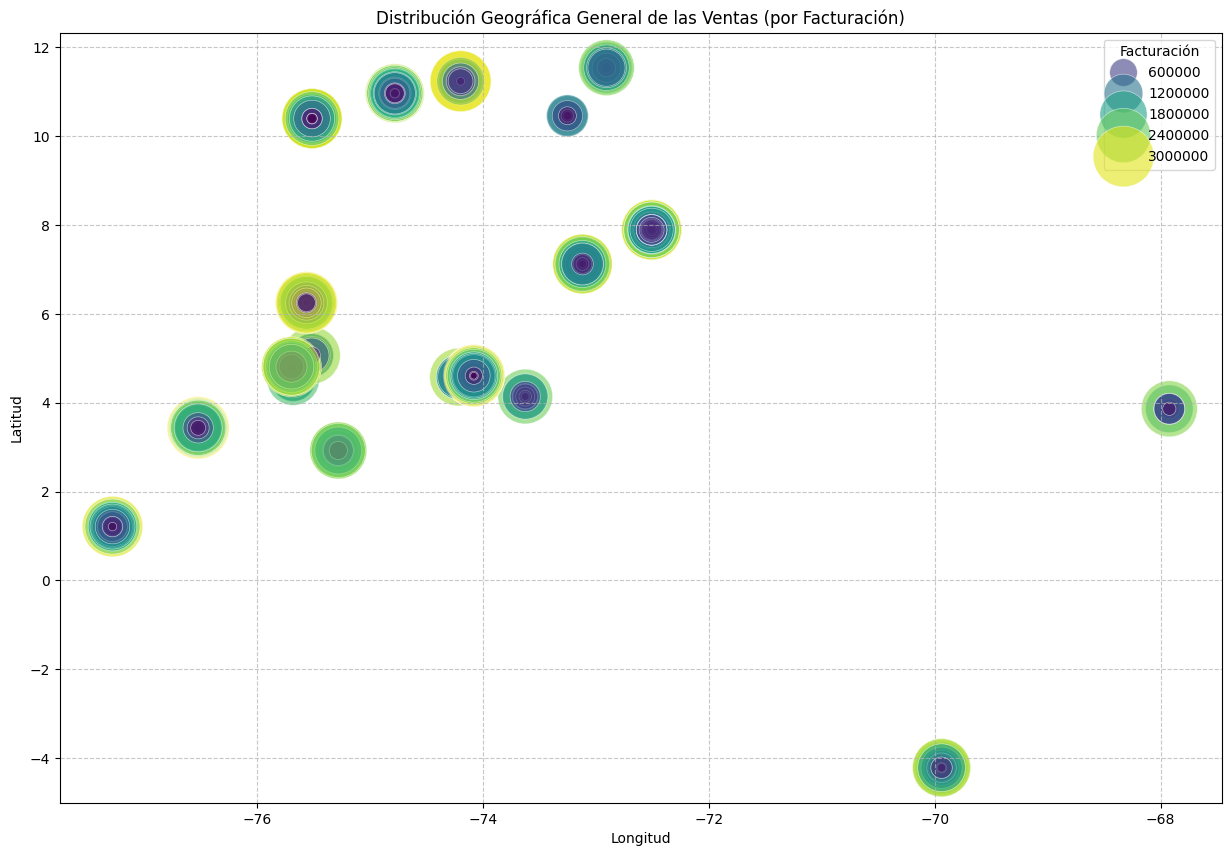

In [12]:
# Plot 1: General geographical distribution of sales by revenue
plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=df_total_geo,
    x='lon',
    y='lat',
    size='Facturación', # Size of points based on sales
    hue='Facturación', # Color of points based on sales
    palette='viridis', # Colormap
    alpha=0.6,
    sizes=(20, 2000) # Range of marker sizes
)
plt.title('Distribución Geográfica General de las Ventas (por Facturación)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

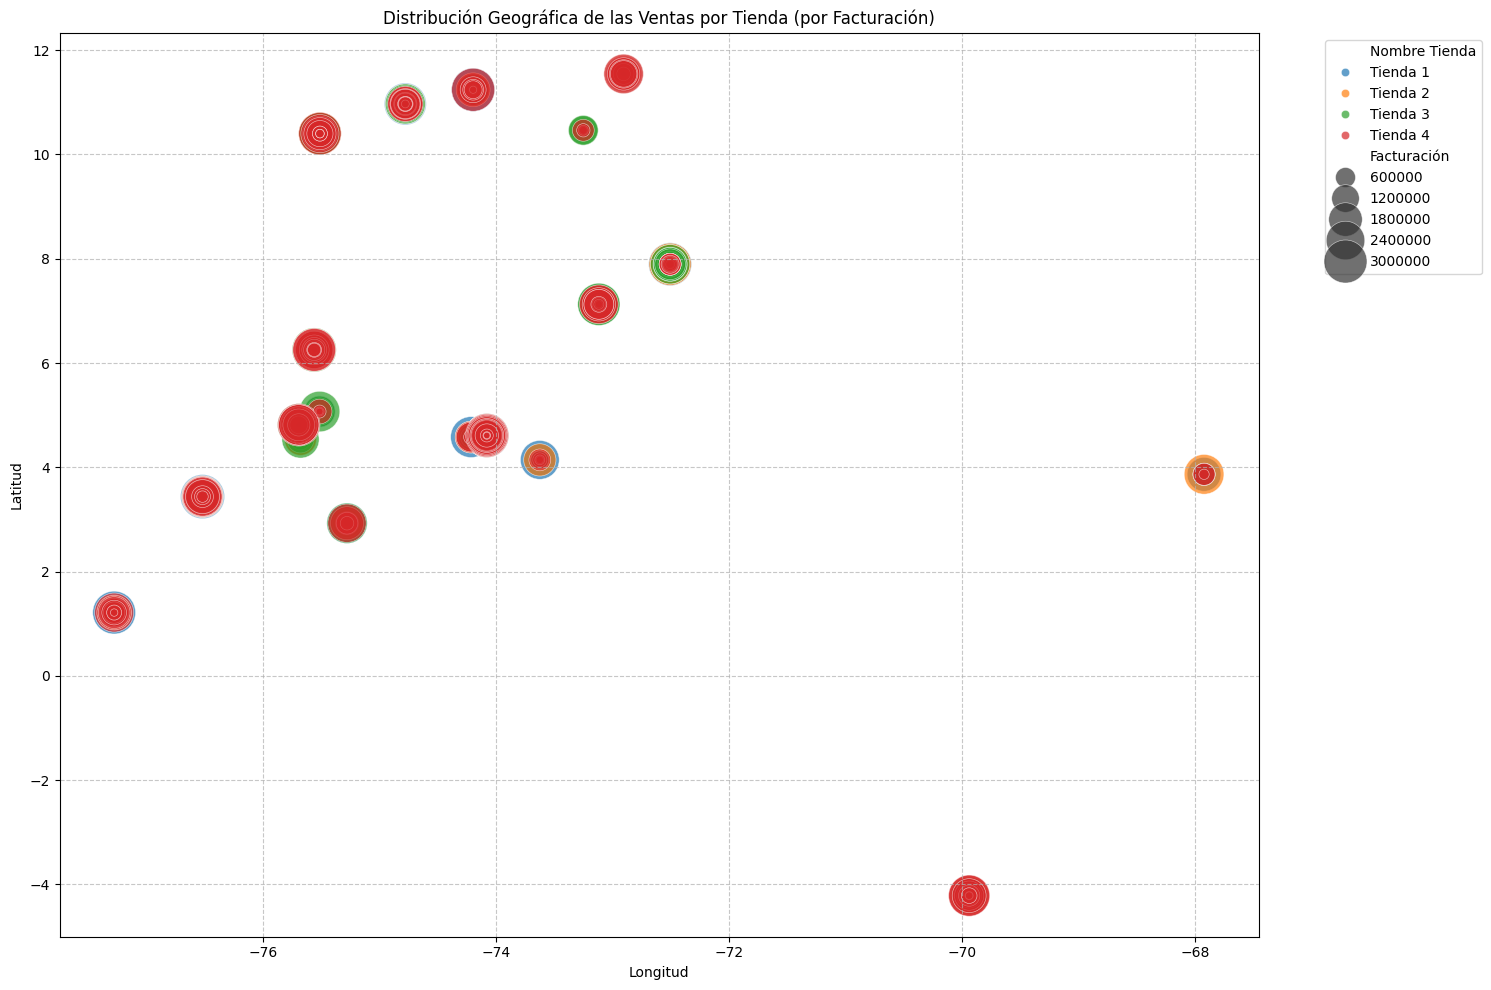

In [13]:
# Plot 2: Geographical distribution of sales, differentiated by store
plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=df_total_geo,
    x='lon',
    y='lat',
    hue='Nombre Tienda', # Differentiate by store
    size='Facturación', # Size of points based on sales
    sizes=(20, 1000), # Adjusted for clarity with multiple hues
    alpha=0.7,
    palette='tab10'
)
plt.title('Distribución Geográfica de las Ventas por Tienda (por Facturación)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.tight_layout()
plt.show()

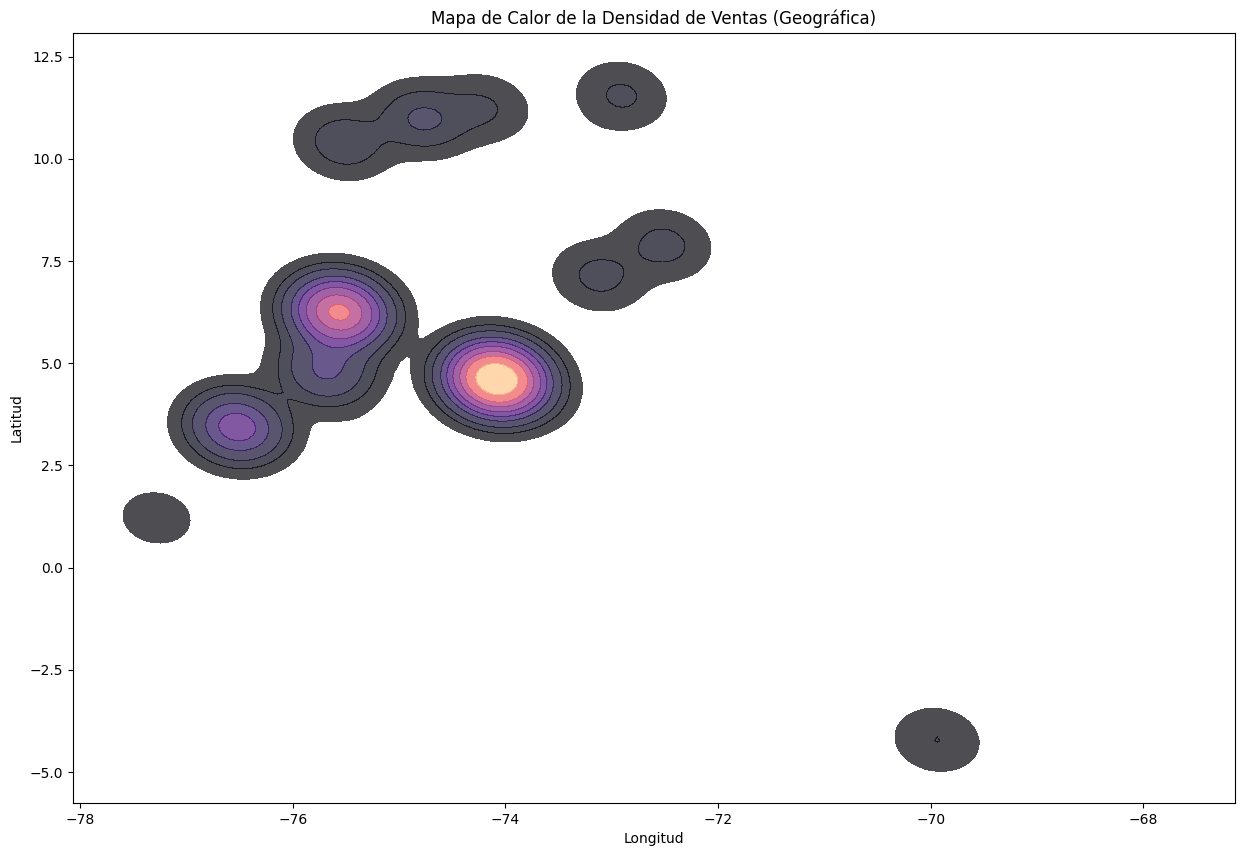

In [14]:
# Plot 3: Heatmap for sales density using Kernel Density Estimate (KDE plot)
plt.figure(figsize=(15, 10))
sns.kdeplot(
    data=df_total_geo,
    x='lon',
    y='lat',
    fill=True,
    cmap='magma',
    alpha=0.7,
    levels=10 # Number of contour levels
)
plt.title('Mapa de Calor de la Densidad de Ventas (Geográfica)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Análisis de la Distribución Geográfica de Ventas

Los gráficos anteriores nos proporcionan una perspectiva geoespacial de las ventas y la facturación de las tiendas:

1.  **Distribución General de Ventas por Facturación:** El primer gráfico de dispersión muestra todos los puntos de venta. El tamaño y el color de cada punto representan la facturación de esa transacción, permitiéndonos identificar áreas con mayor concentración de ventas o transacciones de alto valor.

2.  **Distribución de Ventas por Tienda:** El segundo gráfico de dispersión diferencia las ventas por cada una de las cuatro tiendas ('Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'). Esto es crucial para observar si cada tienda atiende a regiones geográficas distintas o si hay solapamiento. Podemos ver qué tiendas tienen una huella geográfica más amplia o más concentrada, y cómo se distribuyen sus ventas en términos de facturación.

3.  **Mapa de Calor de la Densidad de Ventas:** El mapa de calor (KDE plot) nos ayuda a visualizar las áreas con la mayor densidad de transacciones de ventas. Las zonas más brillantes o intensas en el mapa indican una mayor concentración de actividad de ventas. Esto puede ser útil para identificar "puntos calientes" geográficos que podrían ser objetivos para futuras expansiones o estrategias de marketing dirigidas.

Al analizar estos gráficos, se pueden buscar patrones como:

*   **Concentración Geográfica:** ¿Las ventas están dispersas uniformemente o se concentran en ciertas ciudades o barrios?
*   **Rendimiento Regional por Tienda:** ¿Alguna tienda domina una región específica? ¿Hay regiones donde una tienda tiene baja presencia pero las ventas en general son altas, indicando una oportunidad?
*   **Relación con la Facturación:** ¿Las áreas con alta densidad de ventas también corresponden a alta facturación? ¿O hay muchas transacciones pequeñas en un área, y pocas pero grandes en otra?

Este análisis geográfico complementa el informe final y podría ofrecer ideas adicionales sobre la estrategia de venta de las tiendas.